In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

In [ ]:
df = pd.read_excel("data/sales_data.xlsx")

In [36]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Unmarried,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Unmarried,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  object 
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Sector            11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(3), object(9)
memory usage: 1.2+ MB


In [38]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Sector              0
Product_Category    0
Orders              0
Amount              0
dtype: int64

- Unique values of columns - (State, Zone, Product_Category)

In [8]:
State = df["State"].unique()

State = pd.DataFrame(State)

State

State.to_csv("Unique States.csv", index=False)

In [9]:
Zone = df["Zone"].unique()

Zone = pd.DataFrame(Zone)

Zone

Zone.to_csv("Unique Zones.csv", index = False)

In [10]:
Products = df["Product_Category"].unique()

Products = pd.DataFrame(Products)

Products

Products.to_csv("Unique Products.csv", index = False)

In [12]:
Sector = df["Sector"].unique()

Sector = pd.DataFrame(Sector)

Sector

Sector.to_csv("Unique Sectors.csv", index = False)

# Data Cleaning --
- Changed column name from Occupation to Sector

In [11]:
df.rename(columns = {"Occupation" : "Sector"}, inplace = True)

- Replaced values 0 and 1 to married & Single from Marital_Status column

In [13]:
df["Marital_Status"] = df["Marital_Status"].astype(str).str.replace("1", "Married")
df["Marital_Status"] = df["Marital_Status"].astype(str).str.replace("0", "Unmarried")

- Delete NAN Values columns from data(unnamed, status)

In [14]:
df = df.drop({"unnamed1","Status"}, axis=1)

- drop null Values from Data

In [15]:
df = df.dropna()

# Data Visualisation

# Count plot (Age group wise Gender)

In [17]:
colors = [
    "#E3F2FD",
    "#BBDEFB",
    "#90CAF9",
    "#64B5F6",
    "#42A5F5",
    "#2196F3",
    "#1E88E5",
    "#1565C0",
    "#0D47A1",
]

In [18]:
df["Age Group"].unique()

array(['26-35', '0-17', '18-25', '51-55', '46-50', '55+', '36-45'],
      dtype=object)

# Countplot (Age Group wise Gender)

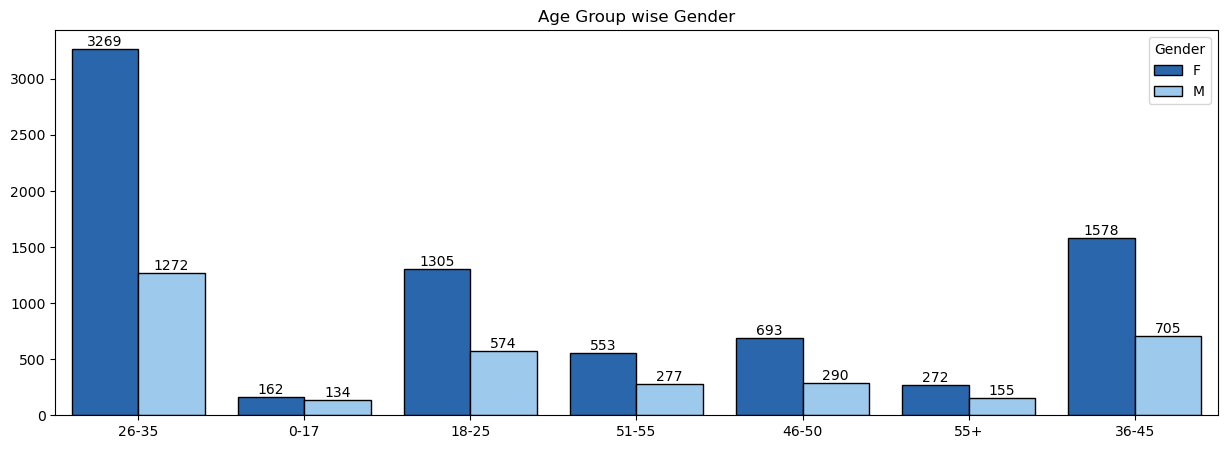

In [19]:
plt.figure(figsize = (15,5))

A1 = sns.countplot(x = "Age Group", data = df, hue = "Gender", palette=["#1565C0","#90CAF9"],edgecolor = "black")

plt.title("Age Group wise Gender")

plt.xlabel("")

plt.ylabel("")

for y in A1.containers:
    A1.bar_label(y)

plt.show()

- Remarks- this graph shows number of people in perticular age group. we can see, Female are higher in number in every age group.

- Conclusion- 
1. Target Females most for the product sales.
2. also, those who comes under 26-35, target them more as they are higher in numbers.
3. for thos who are less, come with those products which are usable for them according to there age.


# Line Chart (Sector wise Orders)

In [20]:
T1 = df.groupby("Sector", as_index = False)["Orders"].sum().sort_values(by="Orders",ascending=False)

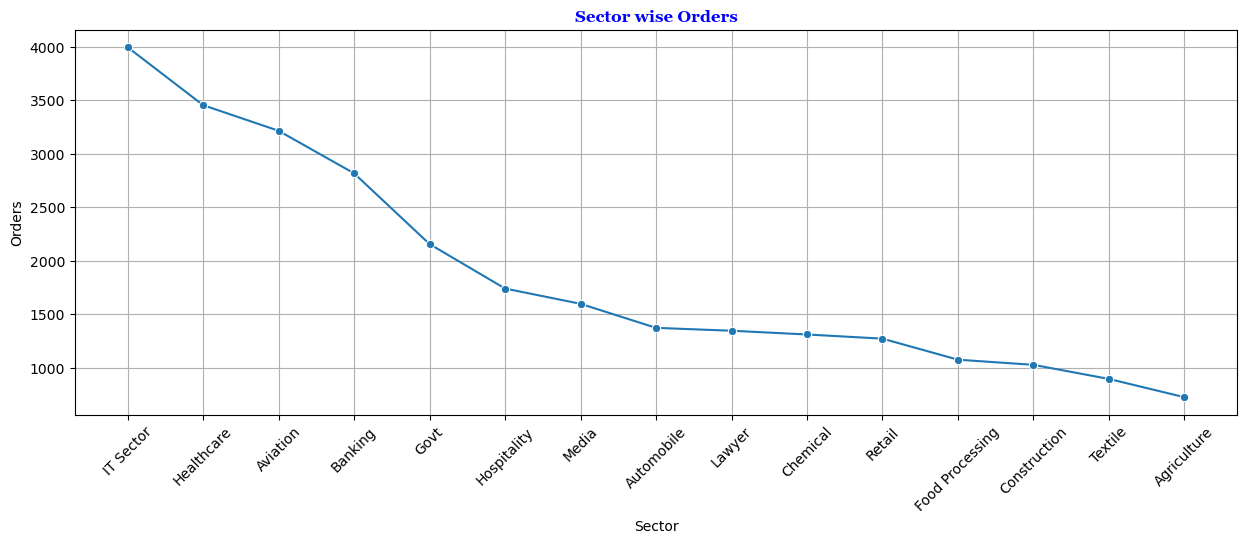

In [42]:
plt.figure(figsize = (15,5))

sns.lineplot(x = T1["Sector"], y = T1["Orders"], data = T1, ci = None, marker = "o")

plt.title("Sector wise Orders",family="Georgia",fontweight="bold",color="blue")

plt.xlabel("Sector")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.grid()

plt.show()

- Remarks-
Orders are Heavily concentrated in tech and core services like IT and Heakthcare, while traditional sector like Agriculture generate the lowest volume.

- Conclusion-
1. Core Drivers- Tech, Health care, Aviation and Banking generate the highest demand.
2. Large disparity- IT orders are over five times higher than Agriculter orders.
3. Mid-Level stability- Government, Legal and Retail maintain steady moderate order volume.
4. Low adoption- Manufacturing and Agriculture lag significantly at the bottom.

# Bar Chart (State wise Amount)

In [22]:
colors = [
    "#FFF3E0",
    "#FFE0B2",
    "#FFCC80",
    "#FFB74D",
    "#FFA726",
    "#FF9800",
    "#FB8C00",
    "#EF6C00",
    "#E65100",
]

In [23]:
T2 = df.groupby("State", as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False)

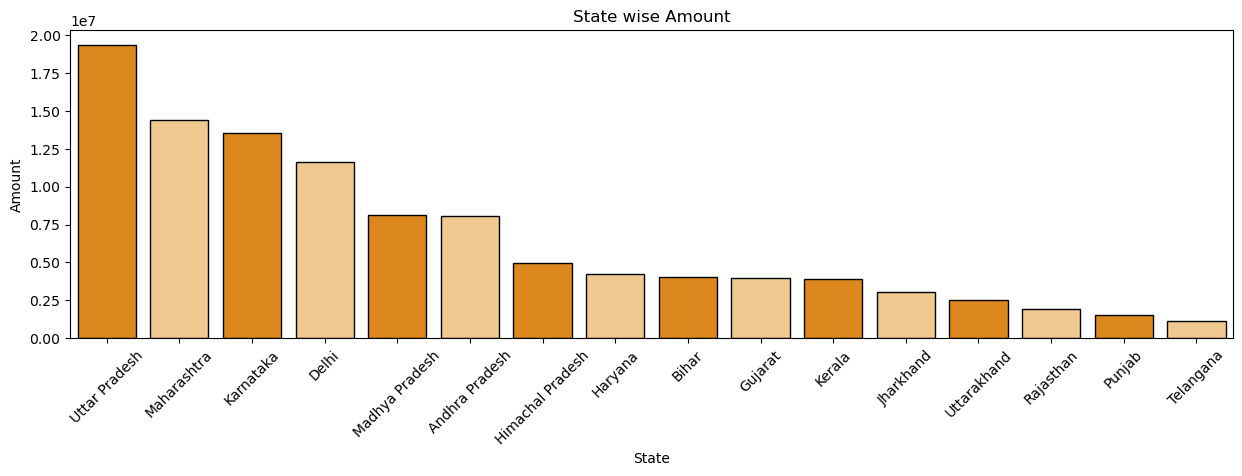

In [24]:
plt.figure(figsize=(15,4))

sns.barplot(x=T2["State"],y=T2["Amount"],data=T2, palette=["#FB8C00","#FFCC80"],edgecolor="black")

plt.title("State wise Amount")

plt.xticks(rotation=45)

plt.show()

- Remark- Uttar Pradesh has the highest total amount, while Telangana has the lowest among the states shown.

- Conclusion-
1. Uttar Pradesh leads with the highest amount.
2. Maharashtra and Karnataka are the next highest contributors.
3. Madhya Pradesh and Andhra Pradesh show moderate amounts.
4. Telangana, Punjab, and Rajasthan have comparatively low amounts.

# State wise Orders-

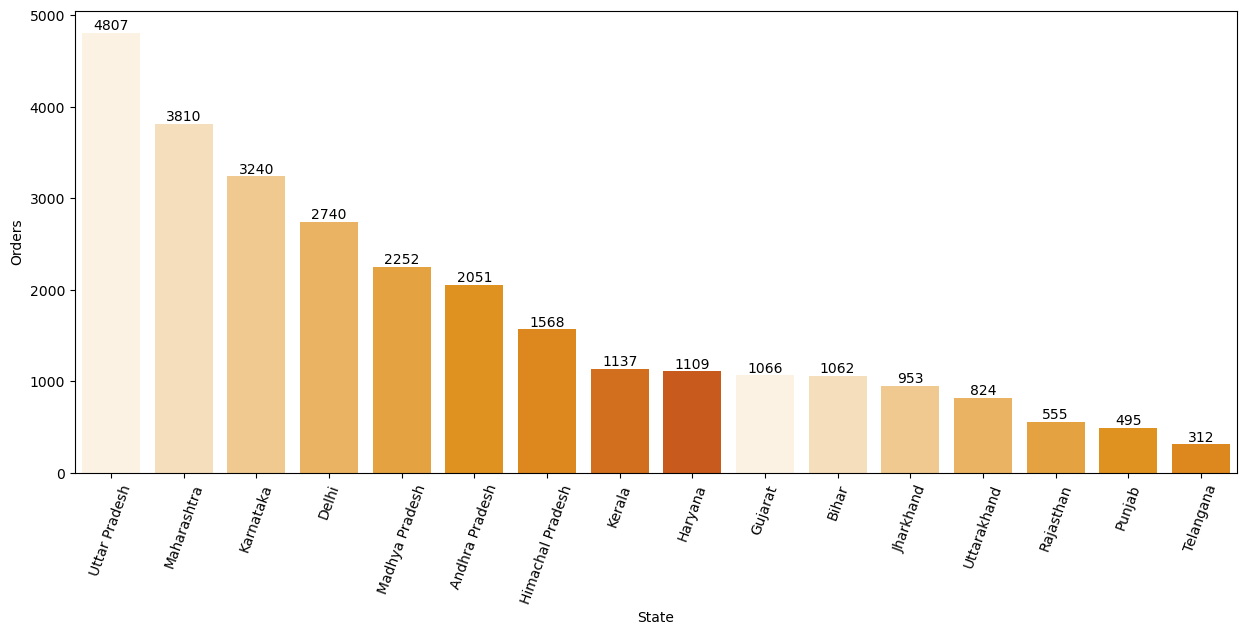

In [25]:
s1 = df.groupby("State", as_index= False)["Orders"].sum().sort_values(by="Orders", ascending=False)


plt.figure(figsize=(15,6))
p1 = sns.barplot(x= s1["State"],y=s1["Orders"], data=s1,palette=colors)

for p in p1.containers:
    p1.bar_label(p)

plt.xticks(rotation=70)

plt.show()

- Remark-
States like-UP, MH, Karnataka, Delhi, MP, AP, HP, kerala, these are the states where orders purchases are high. 

- Conclusion-
1. Target those States where Orders ratio is higher
2. Increase supply in those state where Order Ratio is high.
3. Decrease supply in those state where Order Ratio is Less.

# Pie chart (Zone wise Amount)

In [26]:
T3 = df.groupby("Zone", as_index=False)["Amount"].sum()

In [27]:
C2 = [
    "#42A5F5",
    "#43A047",
    "#E57373",
    "#FF9800",
    "#9C27B0",
]


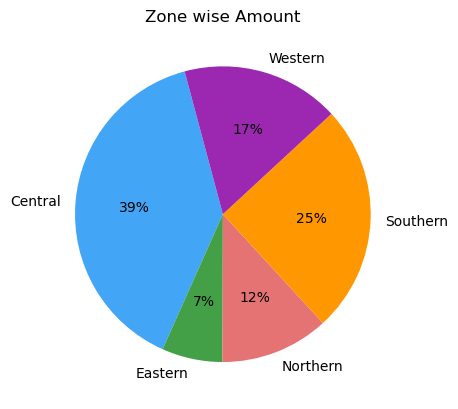

In [28]:
plt.pie(T3["Amount"], labels=T3["Zone"], autopct= "%1.f%%", startangle=105, colors=C2)

plt.title("Zone wise Amount")

plt.show()

- Remark- the Central zone contributes the highest amount (39%), while the Eastern zone contributes the lowest (7%).

- Conclusion-
1. Central zone dominates with 39%.
2. Southern is the second-highest at 25%.
3. Western and Northern contribute 17% and 12% respectively.
4. Eastern has the lowest contribution at 7%.

#  Bar Chart (Sector wise Orders)

In [29]:
colors = [
    "#EFB9BE",
    "#EF9A9A",
    "#E57373",
    "#EF5350",
    "#F44336",
    "#E53935",
    "#C62828",
    "#DB2D2D",
]

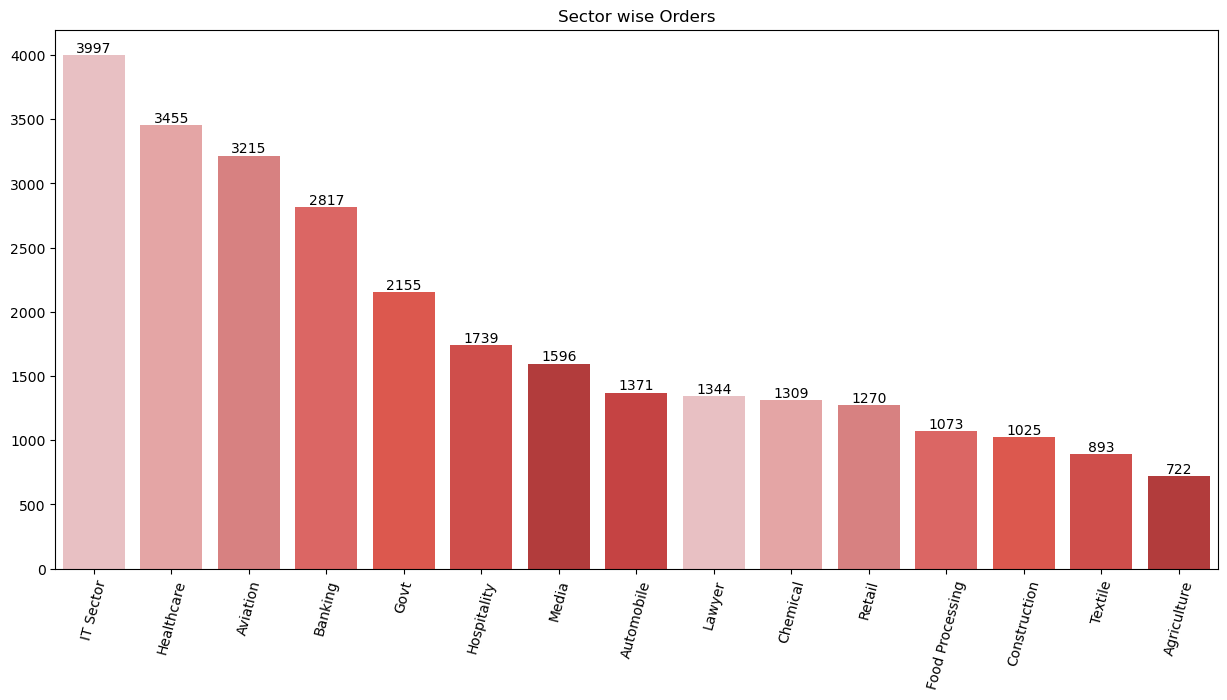

In [30]:
h1 = df.groupby("Sector", as_index= False)["Orders"].sum().sort_values(by="Orders",ascending=False)

plt.figure(figsize=(15,7))

g1 = sns.barplot(x=h1["Sector"],y=h1["Orders"],data=h1,palette=colors)

plt.title("Sector wise Orders")

plt.xticks(rotation=75)

plt.xlabel("")

plt.ylabel("")

for y in g1.containers:
    g1.bar_label(y)
    
plt.show()

- Remarks-
Orders are Heavily concentrated in tech and core services like IT and Heakthcare, while traditional sector like Agriculture generate the lowest volume.

- Conclusion-
1. Core Drivers- Tech, Health care, Aviation and Banking generate the highest demand.
2. Large disparity- IT orders are over five times higher than Agriculter orders.
3. Mid-Level stability- Government, Legal and Retail maintain steady moderate order volume.
4. Low adoption- Manufacturing and Agriculture lag significantly at the bottom.

# Line plot (State wise Orders)

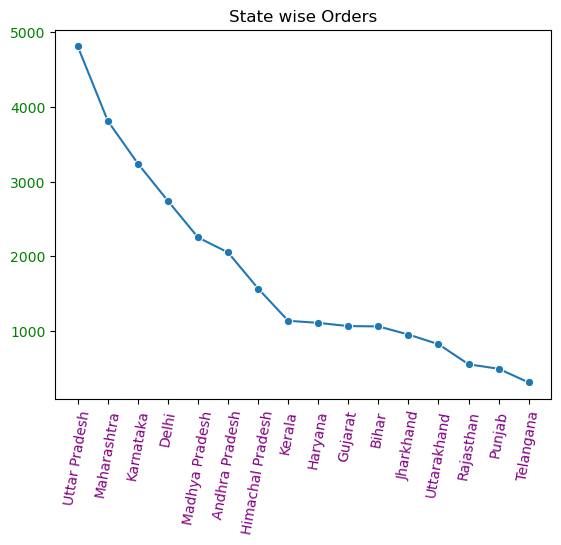

In [31]:
h2 = df.groupby("State", as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False)

sns.lineplot(x=h2["State"],y= h2["Orders"],data=h2, marker="o")

plt.title("State wise Orders")

plt.xticks(rotation = 80, color="purple")

plt.yticks(color="green")

plt.xlabel("")

plt.ylabel("")

plt.show()

- Remark-
States like-UP, MH, Karnataka, Delhi, MP, AP, HP, kerala, these are the states where orders purchases are high. 

- Conclusion-
1. Target those States where Orders ratio is higher
2. Increase supply in those state where Order Ratio is high.
3. Decrease supply in those state where Order Ratio is Less.

# Pie Chart (Product_Catogary wise Orders)

In [32]:
c1 = [
    "#FFCDD2",
    "#FFE0B2",
    "#FFF9C4",
    "#C8E6C9",
    "#B2EBF2",
    "#BBDEFB",
    "#D1C4E9",
    "#F8BBD0",
]

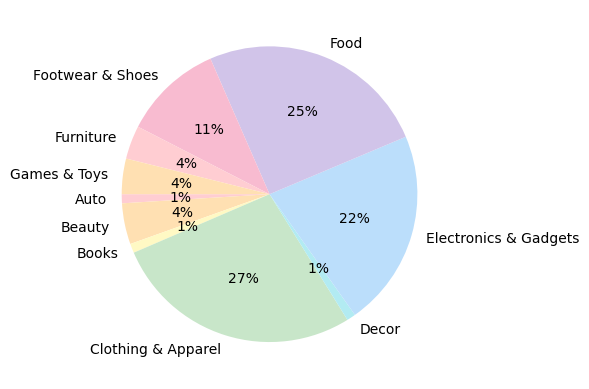

In [33]:
h3 = df.groupby("Product_Category",as_index=False)["Orders"].sum().head(10)

plt.pie(h3["Orders"],labels=h3["Product_Category"],autopct="%1.f%%",startangle=180,colors=c1)

plt.show()

- Remark- Clothing & Apparel, Food, and Electronics & Gadgets dominate the overall sales/category distribution, while the remaining categories contribute relatively small shares.

- Conclusion-
1. Clothing & Apparel leads with 27%, the highest share.
2. Food (25%) and Electronics & Gadgets (22%) are also major contributors.
3. The top three categories together account for 74% of the total.
4. Decor, Books, and Auto have very small shares of just 1% each, indicating low contribution.


# Married_Status wise Order

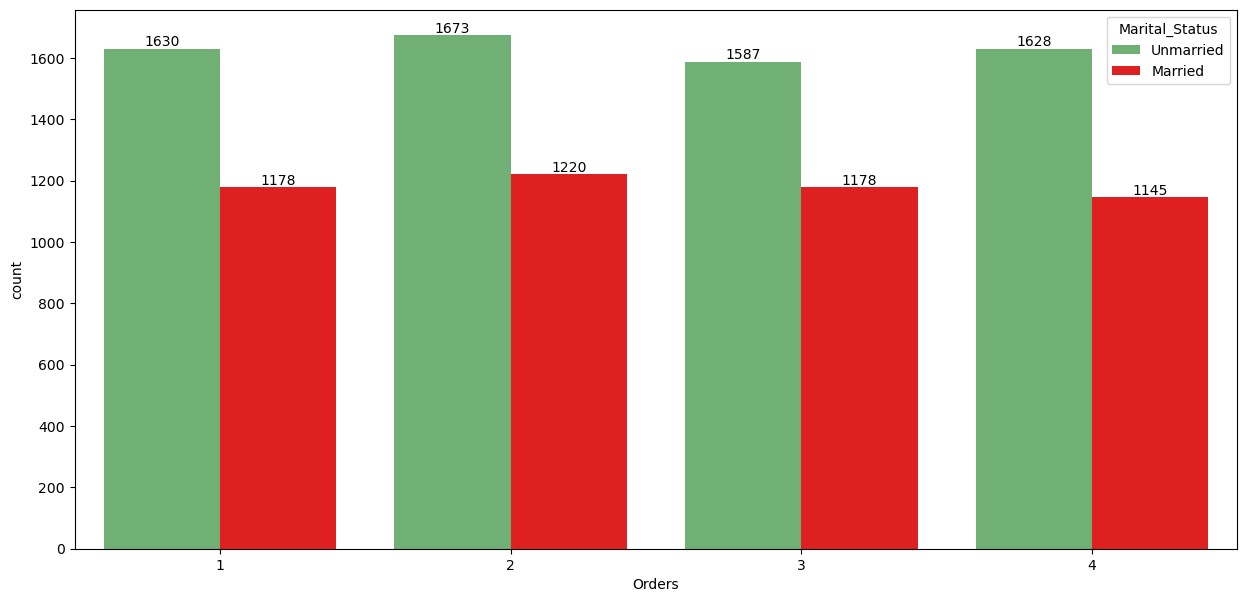

In [34]:
plt.figure(figsize=(15,7))

c1 = sns.countplot(x= "Orders", data=df,hue="Marital_Status", palette=["#66BB6A","red"])

for c in c1.containers:
    c1.bar_label(c)

plt.show()

- Remark-
number of orders been placed by a married person and a single person.


- Conslusion-
1. minimum no. of order is 1
2. maximum no. of order is 4
3. high number of orders are been placed by those who are not married.
4. Married person has placed less orders.

# Pie Chart (Marital_Status wise Ordes)

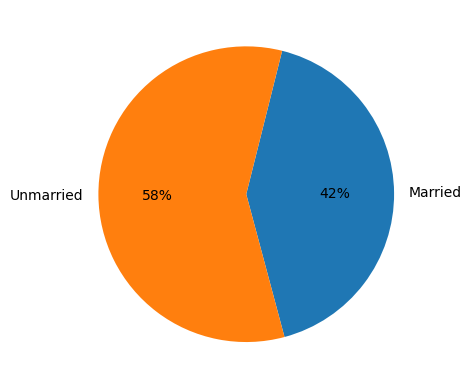

In [35]:
l1 = df.groupby("Marital_Status", as_index=False)["Orders"].sum()

plt.pie(l1["Orders"],labels=l1["Marital_Status"], autopct="%1.f%%",startangle=-75)

plt.show()

- Remarks-
As we can see by this pie chart, the difference of ordering in between married and unmarried.

- Conclusion-
1. high number of orders are been placed by those who are not married.
2. Married person has placed less orders.
3. minimum no. of order is 1
4. maximum no. of order is 4
